<a href="https://colab.research.google.com/github/pallu663/Internships-/blob/main/Copy_of_Retail_Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls

rossmann-store-sales.zip  sample_data


In [ ]:
!unzip rossmann-store-sales.zip

Archive:  rossmann-store-sales.zip
  inflating: sample_submission.csv   
  inflating: store.csv               
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving rossmann-store-sales.zip to rossmann-store-sales (1).zip


In [ ]:
import zipfile
import os

In [ ]:
# Step 1: Find only zip files
zip_files = [f for f in os.listdir() if f.endswith(".zip")]

print("ZIP files found:", zip_files)



ZIP files found: ['rossmann-store-sales (1).zip']


In [ ]:
import pandas as pd
df = pd.read_csv("train.csv")
df.head()

/tmp/ipykernel_1840/1900738286.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
df.shape

(1017209, 9)

In [ ]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [ ]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017208,1115,2,2013-01-01,0,0,0,0,a,1
1016473,379,2,2013-01-01,0,0,0,0,a,1
1016472,378,2,2013-01-01,0,0,0,0,a,1
1016471,377,2,2013-01-01,0,0,0,0,a,1
1016470,376,2,2013-01-01,0,0,0,0,a,1


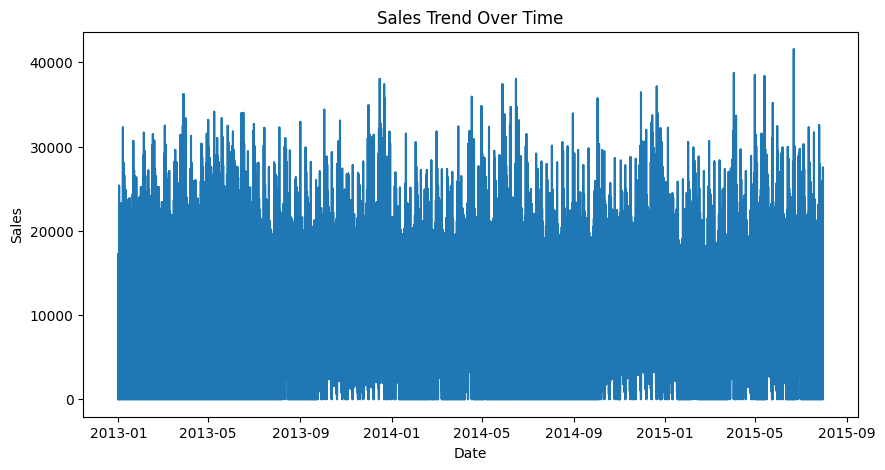

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Sales'])

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

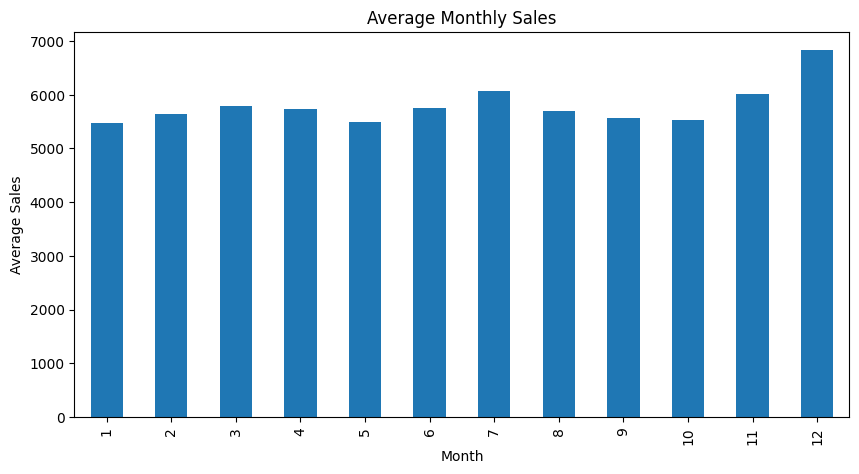

In [ ]:
import matplotlib.pyplot as plt

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract month
df['Month'] = df['Date'].dt.month

# Group by month
monthly_sales = df.groupby('Month')['Sales'].mean()

# Plot
monthly_sales.plot(kind='bar', figsize=(10,5))

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

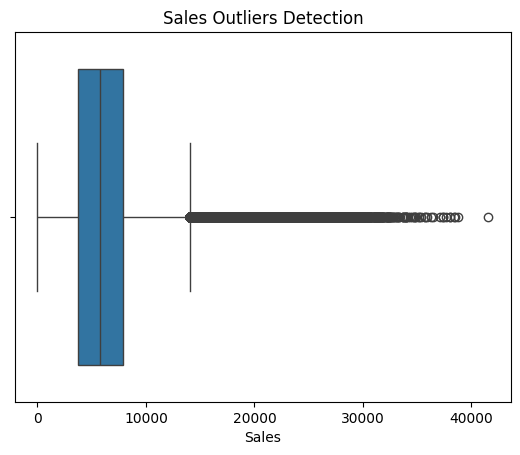

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Sales'])

plt.title("Sales Outliers Detection")
plt.show()

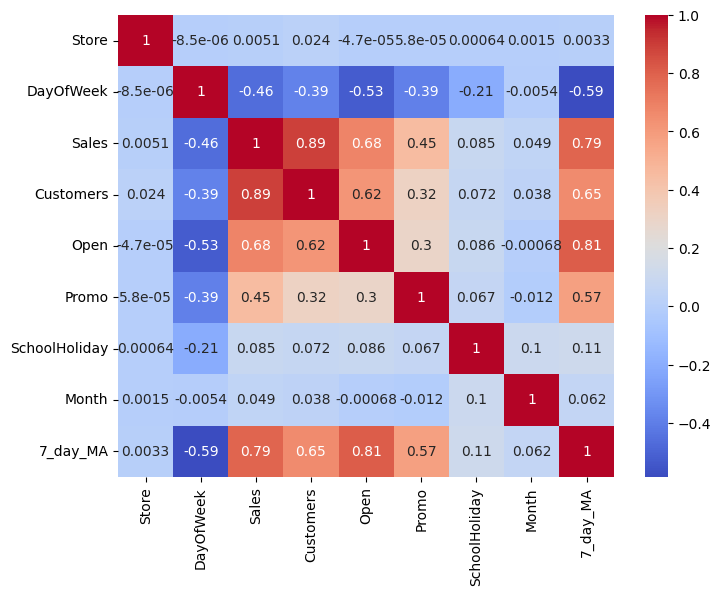

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df.columns = df.columns.str.strip()
date_col = [c for c in df.columns if 'date' in c.lower()][0]
df = df.sort_values(by=date_col)

In [ ]:
print(df.columns)
print(df.head())

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Month', '7_day_MA'],
      dtype='object')
     Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0     1115          2 2013-01-01      0          0     0      0            a   
734   1112          2 2013-01-01      0          0     0      0            a   
735   1111          2 2013-01-01      0          0     0      0            a   
736   1110          2 2013-01-01      0          0     0      0            a   
737   1109          2 2013-01-01      0          0     0      0            a   

     SchoolHoliday  Month  7_day_MA  
0                1      1       NaN  
734              1      1       NaN  
735              1      1       NaN  
736              1      1       NaN  
737              1      1       NaN  


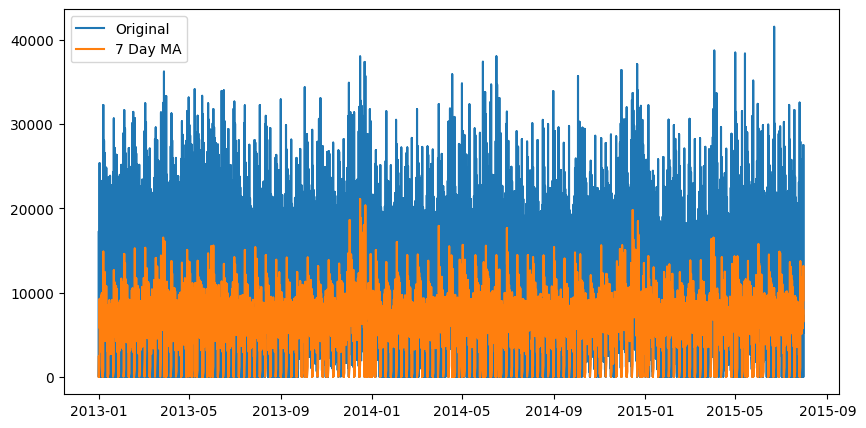

In [ ]:
df.columns = df.columns.str.strip()
sales_col = [c for c in df.columns if 'sales' in c.lower()][0]
df[sales_col] = pd.to_numeric(df[sales_col], errors='coerce')
df['7_day_MA'] = df[sales_col].rolling(window=7).mean()

plt.figure(figsize=(10,5))
plt.plot(df[date_col], df[sales_col], label='Original')
plt.plot(df[date_col], df['7_day_MA'], label='7 Day MA')
plt.legend()
plt.show()

In [ ]:
df.to_csv("updated_train.csv", index=False)

In [ ]:
import os
print(os.listdir())

['.config', 'sample_submission.csv', 'store.csv', 'train.csv', 'rossmann-store-sales (1).zip', 'test.csv', '.ipynb_checkpoints', 'updated_train.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

df.columns = df.columns.str.strip()
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])

df.head()


/tmp/ipykernel_1840/2399749405.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
df['year'] = df[date_col].dt.year
df['month'] = df[date_col].dt.month
df['day'] = df[date_col].dt.day
df['weekofyear'] = df[date_col].dt.isocalendar().week

In [ ]:
print(df.columns)

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'year', 'month', 'day', 'weekday',
       'weekofyear'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip()
df['lag_1'] = df['Sales'].shift(1)
df['lag_7'] = df['Sales'].shift(7)

In [ ]:
import pandas as pd

df.columns = df.columns.str.strip()
df.rename(columns={'Sales': 'sales'}, inplace=True)
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

df['rolling_mean_7'] = df['sales'].rolling(window=7, min_periods=1).mean()

In [ ]:
print(df.columns)

Index(['Store', 'DayOfWeek', 'Date', 'sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'year', 'month', 'day', 'weekday',
       'weekofyear', 'lag_1', 'lag_7', 'rolling_mean_7'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_family = LabelEncoder()
df['family'] = le_family.fit_transform(df['family'])
df.head()

,Store,DayOfWeek,Date,sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,year,month,day,weekday,weekofyear,lag_1,lag_7,rolling_mean_7,family
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,4,31,NaN,NaN,5263.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,4,31,5263.0,NaN,5663.5,0
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,4,31,6064.0,NaN,6547.0,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,4,31,8314.0,NaN,8409.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,4,31,13995.0,NaN,7691.6,0


In [ ]:
print(df.columns)

Index(['Store', 'DayOfWeek', 'Date', 'sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'year', 'month', 'day', 'weekday',
       'weekofyear', 'lag_1', 'lag_7', 'rolling_mean_7', 'family'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['store', 'dayofweek', 'date', 'sales', 'customers', 'open', 'promo',
       'stateholiday', 'schoolholiday', 'year', 'month', 'day', 'weekday',
       'weekofyear', 'lag_1', 'lag_7', 'rolling_mean_7', 'family'],
      dtype='object')


In [ ]:
df.rename(columns={'on_promotion': 'onpromotion'}, inplace=True)

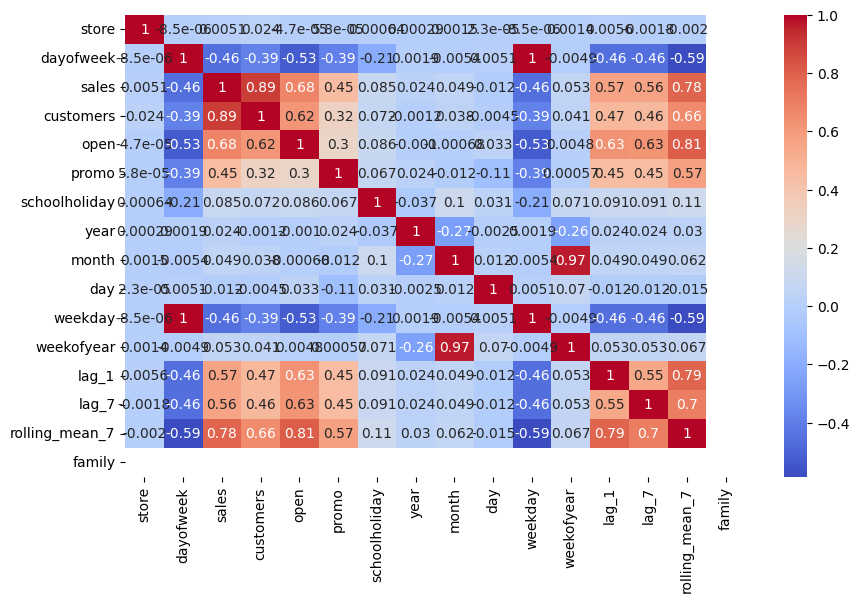

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
df.to_csv("feature_engineered_sales.csv", index=False)

In [ ]:
df = df.dropna()

In [ ]:
df.columns = df.columns.str.strip()

X = df.drop(columns=['sales', 'date', 'id'], errors='ignore')
y = df['sales']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = df.dropna()

X = df.drop(['sales'], axis=1)
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()

In [ ]:
print(df.columns)

Index(['store', 'dayofweek', 'sales', 'customers', 'open', 'promo',
       'stateholiday', 'schoolholiday', 'year', 'month', 'day', 'weekday',
       'weekofyear', 'lag_1', 'lag_7', 'rolling_mean_7', 'family'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['store', 'dayofweek', 'sales', 'customers', 'open', 'promo',
       'stateholiday', 'schoolholiday', 'year', 'month', 'day', 'weekday',
       'weekofyear', 'lag_1', 'lag_7', 'rolling_mean_7', 'family'],
      dtype='object')


In [ ]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
else:
    print("❌ No date column found")
    print(df.columns)

❌ No date column found
Index(['store', 'dayofweek', 'sales', 'customers', 'open', 'promo',
       'stateholiday', 'schoolholiday', 'year', 'month', 'day', 'weekday',
       'weekofyear', 'lag_1', 'lag_7', 'rolling_mean_7', 'family'],
      dtype='object')


In [ ]:
df = df.sort_values('date')

df_ts = df.groupby('date')['sales'].sum().reset_index()

df_ts.set_index('date', inplace=True)

df_ts.head()

,sales
date,
2013-01-01,97235
2013-01-02,6949829
2013-01-03,6347820
2013-01-04,6638954
2013-01-05,5951593


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_ts['sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary ✅")
else:
    print("Data is NOT Stationary ❌ (Use differencing)")

ADF Statistic: -4.761614524595615
p-value: 6.436731330559343e-05
Data is Stationary ✅


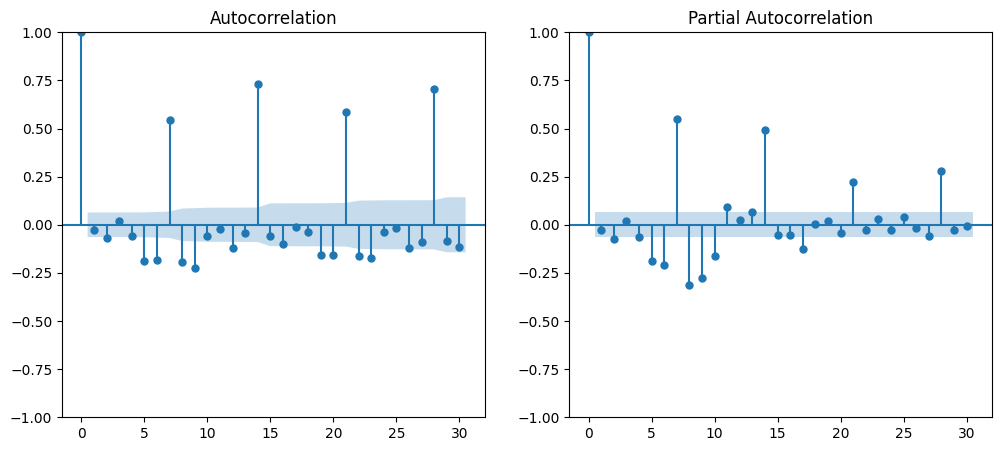

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(df_ts['sales'], ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(df_ts['sales'], ax=plt.gca())

plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Set frequency (IMPORTANT FIX)
df_ts = df_ts.asfreq('D')

# Fill missing values (important after asfreq)
df_ts['sales'] = df_ts['sales'].fillna(method='ffill')

# ARIMA model
model_arima = ARIMA(df_ts['sales'], order=(1,1,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

/tmp/ipykernel_2622/3031070679.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ts['sales'] = df_ts['sales'].fillna(method='ffill')


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  942
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -15428.467
Date:                Wed, 15 Apr 2026   AIC                          30862.935
Time:                        03:41:32   BIC                          30877.476
Sample:                    01-01-2013   HQIC                         30868.478
                         - 07-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0247      0.038     -0.643      0.520      -0.100       0.051
ma.L1         -0.9926      0.006   -156.483      0.000      -1.005      -0.980
sigma2      1.273e+13        nan        nan        n

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(df_ts['sales'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,12))  # 12 = monthly seasonality

model_sarima_fit = model_sarima.fit()

print(model_sarima_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                  942
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -15480.169
Date:                            Wed, 15 Apr 2026   AIC                          30970.339
Time:                                    03:41:55   BIC                          30994.509
Sample:                                01-01-2013   HQIC                         30979.558
                                     - 07-31-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0256      0.105     -0.244      0.808      -0.232       0.180
ma.L1         -0.9675      0.037   

In [ ]:
forecast_arima = model_arima_fit.forecast(steps=30)
forecast_sarima = model_sarima_fit.forecast(steps=30)

print("ARIMA Forecast:\n", forecast_arima)
print("SARIMA Forecast:\n", forecast_sarima)

ARIMA Forecast:
 2015-08-01    6.387588e+06
2015-08-02    6.479421e+06
2015-08-03    6.477155e+06
2015-08-04    6.477211e+06
2015-08-05    6.477209e+06
2015-08-06    6.477209e+06
2015-08-07    6.477209e+06
2015-08-08    6.477209e+06
2015-08-09    6.477209e+06
2015-08-10    6.477209e+06
2015-08-11    6.477209e+06
2015-08-12    6.477209e+06
2015-08-13    6.477209e+06
2015-08-14    6.477209e+06
2015-08-15    6.477209e+06
2015-08-16    6.477209e+06
2015-08-17    6.477209e+06
2015-08-18    6.477209e+06
2015-08-19    6.477209e+06
2015-08-20    6.477209e+06
2015-08-21    6.477209e+06
2015-08-22    6.477209e+06
2015-08-23    6.477209e+06
2015-08-24    6.477209e+06
2015-08-25    6.477209e+06
2015-08-26    6.477209e+06
2015-08-27    6.477209e+06
2015-08-28    6.477209e+06
2015-08-29    6.477209e+06
2015-08-30    6.477209e+06
Freq: D, Name: predicted_mean, dtype: float64
SARIMA Forecast:
 2015-08-01    6.601748e+06
2015-08-02    7.393816e+06
2015-08-03    6.767812e+06
2015-08-04    6.969172e+06
2

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving rossmann-store-sales.zip to rossmann-store-sales.zip


In [ ]:
import os
print(os.listdir())

['.config', 'test.csv', 'sample_submission.csv', 'store.csv', 'rossmann-store-sales.zip', '.ipynb_checkpoints', 'train.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

/tmp/ipykernel_2622/4047742887.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['store', 'dayofweek', 'date', 'sales', 'customers', 'open', 'promo',
       'stateholiday', 'schoolholiday'],
      dtype='object')


In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [ ]:
print(df.columns)

Index(['store', 'dayofweek', 'date', 'sales', 'customers', 'open', 'promo',
       'stateholiday', 'schoolholiday', 'year', 'month', 'day'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X = df[['store', 'dayofweek', 'promo', 'year', 'month', 'day']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

sample_size = min(5000, len(X_train))

X_train_small = X_train.sample(sample_size, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_small, y_train_small)

RandomForestRegressor(max_depth=10, n_estimators=10, n_jobs=-1, random_state=42)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df_ts['sales'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  942
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -15428.467
Date:                Wed, 15 Apr 2026   AIC                          30862.935
Time:                        04:12:34   BIC                          30877.476
Sample:                    01-01-2013   HQIC                         30868.478
                         - 07-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0247      0.038     -0.643      0.520      -0.100       0.051
ma.L1         -0.9926      0.006   -156.483      0.000      -1.005      -0.980
sigma2      1.273e+13        nan        nan        n

In [ ]:
forecast = model_fit.forecast(steps=30)

print(forecast)

2015-08-01    6.387588e+06
2015-08-02    6.479421e+06
2015-08-03    6.477155e+06
2015-08-04    6.477211e+06
2015-08-05    6.477209e+06
2015-08-06    6.477209e+06
2015-08-07    6.477209e+06
2015-08-08    6.477209e+06
2015-08-09    6.477209e+06
2015-08-10    6.477209e+06
2015-08-11    6.477209e+06
2015-08-12    6.477209e+06
2015-08-13    6.477209e+06
2015-08-14    6.477209e+06
2015-08-15    6.477209e+06
2015-08-16    6.477209e+06
2015-08-17    6.477209e+06
2015-08-18    6.477209e+06
2015-08-19    6.477209e+06
2015-08-20    6.477209e+06
2015-08-21    6.477209e+06
2015-08-22    6.477209e+06
2015-08-23    6.477209e+06
2015-08-24    6.477209e+06
2015-08-25    6.477209e+06
2015-08-26    6.477209e+06
2015-08-27    6.477209e+06
2015-08-28    6.477209e+06
2015-08-29    6.477209e+06
2015-08-30    6.477209e+06
Freq: D, Name: predicted_mean, dtype: float64


In [ ]:
# Create future dates
future_dates = pd.date_range(start=df_ts.index[-1], periods=31)[1:]

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Sales': forecast
})

forecast_df.head()


,Date,Predicted_Sales
2015-08-01,2015-08-01,6.387588e+06
2015-08-02,2015-08-02,6.479421e+06
2015-08-03,2015-08-03,6.477155e+06
2015-08-04,2015-08-04,6.477211e+06
2015-08-05,2015-08-05,6.477209e+06


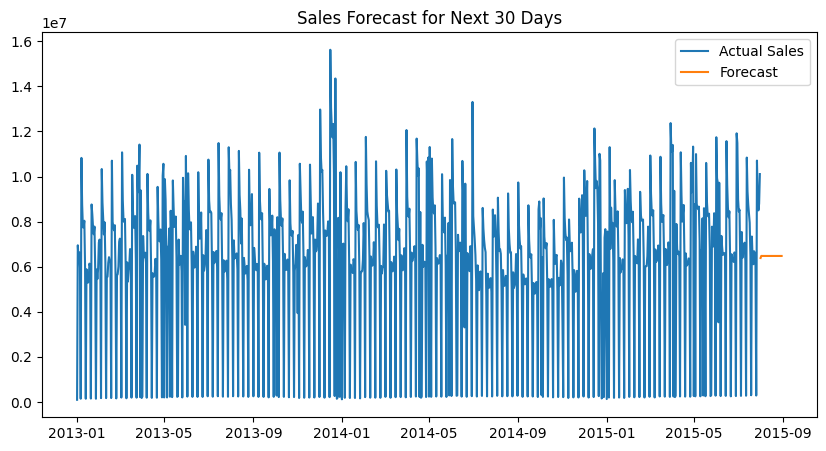

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_ts.index, df_ts, label='Actual Sales')
plt.plot(forecast_df['Date'], forecast_df['Predicted_Sales'], label='Forecast')

plt.legend()
plt.title("Sales Forecast for Next 30 Days")

plt.show()

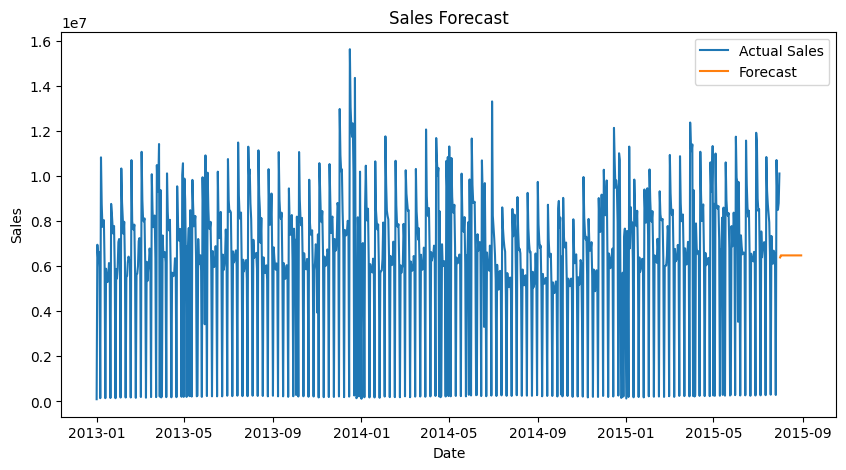

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Actual vs Forecast
plt.plot(df_ts.index, df_ts, label='Actual Sales')
plt.plot(forecast_df['Date'], forecast_df['Predicted_Sales'], label='Forecast')

plt.legend()
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()


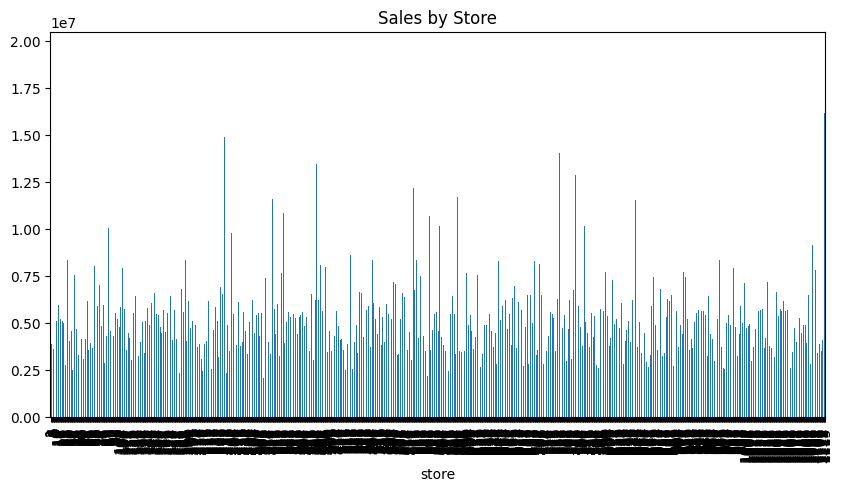

In [ ]:
import matplotlib.pyplot as plt

# Group by store
store_sales = df.groupby('store')['sales'].sum()

# Plot
store_sales.plot(kind='bar', figsize=(10,5), title="Sales by Store")

plt.show()

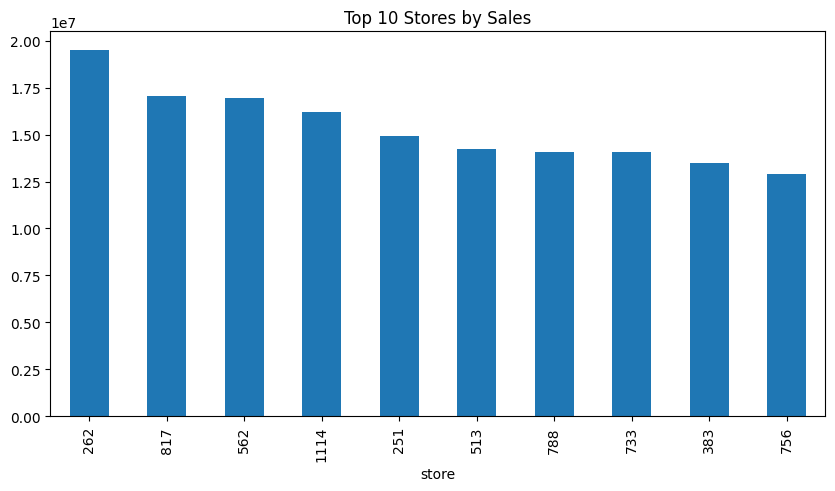

In [ ]:
import matplotlib.pyplot as plt

# Group by store
family_sales = df.groupby('store')['sales'].sum().sort_values(ascending=False).head(10)

# Plot
family_sales.plot(kind='bar', figsize=(10,5), title="Top 10 Stores by Sales")

plt.show()

In [ ]:
import plotly.express as px

fig = px.line(forecast_df, x='Date', y='Predicted_Sales',
              title="Forecasted Sales (Next 30 Days)")

fig.show()


In [ ]:
# Save forecast
forecast_df.to_csv("forecast_report.csv", index=False)


In [ ]:
# Save only first 10000 rows
df_sample = df.head(10000)

with pd.ExcelWriter("sales_report.xlsx") as writer:
    df_sample.to_excel(writer, sheet_name='Raw Data', index=False)
    forecast_df.to_excel(writer, sheet_name='Forecast', index=False)